In [1]:
import pandas as pd

In [2]:
print(5)

5


In [4]:
df = pd.read_csv('titanic.csv')

from config import data_path
def read_file(data_path):
    return pd.read_csv(data_path)
read_file(data_path)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x90 in position 22: invalid start byte

In [25]:
from config import COLS_DROP
from preprocessing import drop_cols

drop_cols(df, COLS_DROP)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [26]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtype":dtypes, "nunique": nunique}).T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
dtype,int64,int64,int64,str,str,float64,int64,int64,object,float64,str,str
nunique,891,2,3,891,2,88,7,7,681,248,147,3


In [ ]:
df.info()

In [15]:
cat_cols=["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cat_cols] = df[cat_cols].astype("category")


In [28]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtype":dtypes, "nunique": nunique}).T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
dtype,int64,category,category,str,category,float64,category,category,object,float64,str,category
nunique,891,2,3,891,2,88,7,7,681,248,147,3


In [55]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
def get_info(df):
    return pd.DataFrame({"dtype": df.dtypes, "nunique": df.nunique()}).T

get_info(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
dtype,int64,category,category,str,category,float64,category,category,object,float64,str,category
nunique,891,2,3,891,2,88,7,7,681,248,147,3


In [30]:
null=df.isnull().sum()
null

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [66]:
r = (null / 891)*100
r

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [6]:
df = df.dropna(subset=['Embarked'])
df = df.dropna(subset=['Cabin'])



In [7]:
med=df['Age'].median()
df['Age'] = df['Age'].fillna(med,inplace=True)

C:\Users\11\AppData\Local\Temp\ipykernel_29468\526853181.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(med,inplace=True)


In [72]:
df.info()

<class 'pandas.DataFrame'>
Index: 202 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  202 non-null    int64   
 1   Survived     202 non-null    category
 2   Pclass       202 non-null    category
 3   Name         202 non-null    str     
 4   Sex          202 non-null    category
 5   Age          202 non-null    float64 
 6   SibSp        202 non-null    category
 7   Parch        202 non-null    category
 8   Ticket       202 non-null    object  
 9   Fare         202 non-null    float64 
 10  Cabin        202 non-null    str     
 11  Embarked     202 non-null    category
dtypes: category(6), float64(2), int64(1), object(1), str(2)
memory usage: 12.4+ KB


In [8]:
num_cls = df.select_dtypes("number").columns
num_cls
for col in num_cls:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    # print(IQR)
    Up_fence = Q1 + 1.5 * IQR
    lo_fence = Q3 - 1.5 * IQR

    lower_outliers = df[df[col] < lo_fence][col].values
    upper_outliers = df[df[col] > Up_fence][col].values

    df[col]= df[col].replace(lower_outliers, lo_fence)
    df[col]= df[col].replace(upper_outliers, Up_fence)

    

In [34]:
df.describe()

,PassengerId,Age,Fare
count,202.000000,202.000000,202.000000
mean,457.209158,35.819926,61.615813
std,246.770714,12.840832,37.576870
min,54.125000,14.125000,0.000000
25%,263.250000,25.000000,28.959375
50%,457.500000,36.000000,55.000000
75%,681.500000,46.750000,89.776050
max,890.000000,57.625000,120.184387


In [ ]:
pip install Matplotlib

In [ ]:
pip install seaborn

ValueError: num must be an integer with 1 <= num <= 2, not 3

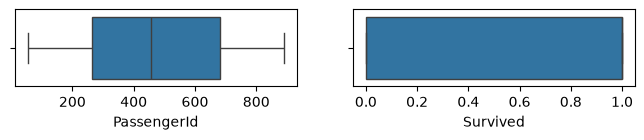

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cls):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')

In [10]:
def replace_outliers(df):
    for col in num_cls:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        # print(Q1, Q3)
        IQR = Q3 -Q1
        lower_fence = Q1  -     1.5 * IQR
        upper_fence = Q3  +     1.5 * IQR
        
        df[col] = df[col].clip(lower_fence,upper_fence)
    return df

ValueError: num must be an integer with 1 <= num <= 2, not 3

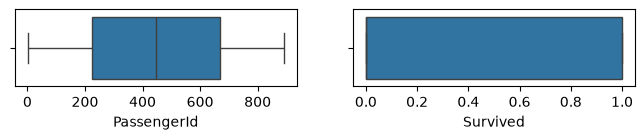

In [57]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cls):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')

In [ ]:
def handle_outliers(df, algo = "iqr", treatment="mediam", multiplier = 1.5):


In [59]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [62]:
def remove_duplicates(df, subset_col = None, keep_strategy = "first"):
    return (df.drop_duplicates(subset = subset_col, keep=keep_strategy).reset_index(drop = True))

In [11]:
num_cls

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

ValueError: num must be an integer with 1 <= num <= 2, not 3

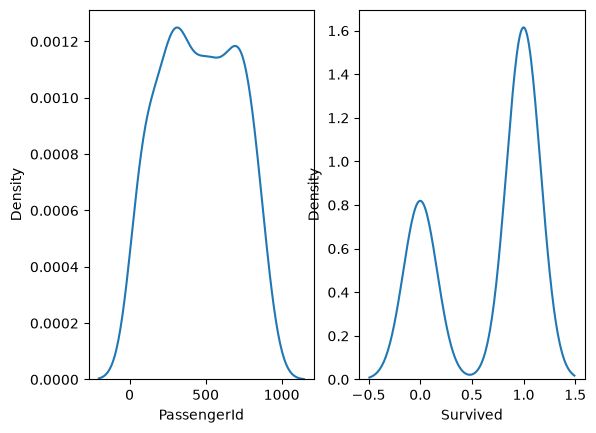

In [13]:
plt.Figure(figsize=(9,2))
for i , col in enumerate(num_cls):
    plt.subplot(1,2, i+1)
    sns.kdeplot(df[col])

plt.show()

In [16]:
cat_cols= df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

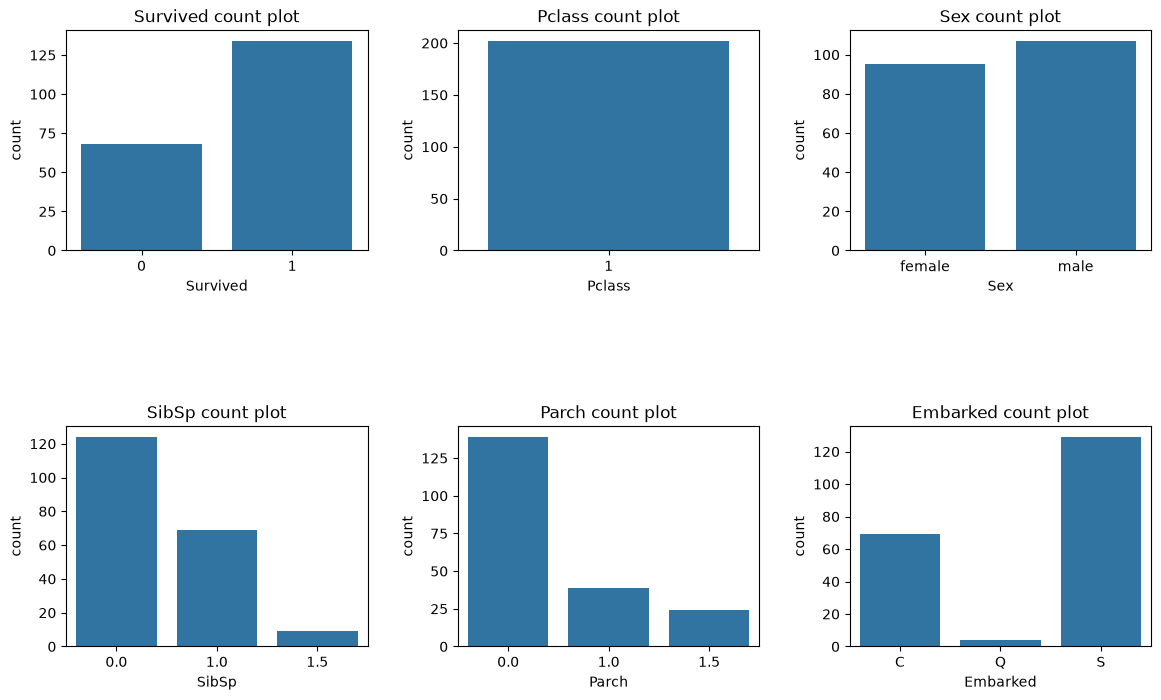

In [ ]:
plt.figure(figsize=(14, 8))  #

for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} count plot")

plt.subplots_adjust(hspace=0.8,wspace=0.3) 
plt.show()

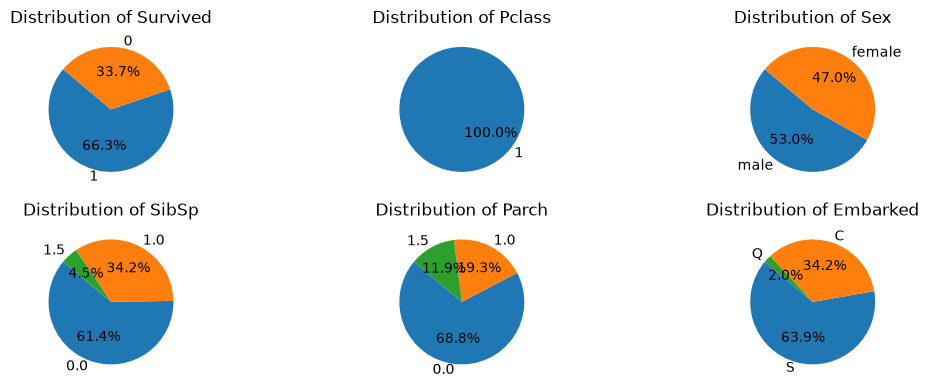

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4    )) 

for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    unique = df[col].value_counts()
    counts = unique.values
    categories = unique.index

    plt.pie(counts, labels=categories, startangle=140, autopct='%1.1f%%')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
unique = df["Survived"].value_counts()
counts=unique.values
categories = unique.index

categories

array([134,  68])

Text(0, 0.5, 'Fare')

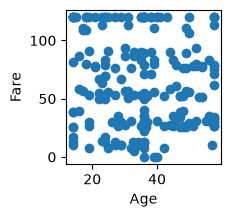

In [35]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')